In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
amp_path = "/content/drive/MyDrive/BIOREGE Cloud/SENSOR/MA-AMP Sensor/MA-AMP ML/AMP linear range-ECL measurement.xlsx"
ma_path = "/content/drive/MyDrive/BIOREGE Cloud/SENSOR/MA-AMP Sensor/MA-AMP ML/MA linear range-ECL measurement.xlsx"

In [2]:
!pip install pandas numpy scikit-learn xgboost catboost openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_CV_SPLITS = 5

AMP_FILE = Path("/content/drive/MyDrive/BIOREGE Cloud/SENSOR/MA-AMP Sensor/MA-AMP ML/AMP linear range-ECL measurement.xlsx")
MA_FILE = Path("/content/drive/MyDrive/BIOREGE Cloud/SENSOR/MA-AMP Sensor/MA-AMP ML/MA linear range-ECL measurement.xlsx")

def load_amp_data(file_path: Path) -> pd.DataFrame:
    if not file_path.exists():
        raise FileNotFoundError(f"AMP file not found: {file_path}")

    raw = pd.read_excel(file_path, header=None)

    concentrations = raw.iloc[0, 2:].values

    data = raw.iloc[2:, [1] + list(range(2, raw.shape[1]))].copy()
    data.columns = ["Voltage"] + list(concentrations)

    long_df = data.melt(
        id_vars="Voltage",
        var_name="Concentration",
        value_name="ECL",
    )

    for column in ["Voltage", "Concentration", "ECL"]:
        long_df[column] = pd.to_numeric(
            long_df[column],
            errors="coerce",
        )

    long_df = long_df.dropna(
        subset=["Voltage", "Concentration", "ECL"]
    ).reset_index(drop=True)

    return long_df

def load_ma_data(file_path: Path) -> pd.DataFrame:
    if not file_path.exists():
        raise FileNotFoundError(f"MA file not found: {file_path}")

    raw = pd.read_excel(file_path, header=None)

    concentrations = raw.iloc[2, 2:].values

    data = raw.iloc[3:, [1] + list(range(2, raw.shape[1]))].copy()
    data.columns = ["Voltage"] + list(concentrations)

    long_df = data.melt(
        id_vars="Voltage",
        var_name="Concentration",
        value_name="ECL",
    )

    for column in ["Voltage", "Concentration", "ECL"]:
        long_df[column] = pd.to_numeric(
            long_df[column],
            errors="coerce",
        )

    long_df = long_df.dropna(
        subset=["Voltage", "Concentration", "ECL"]
    ).reset_index(drop=True)

    return long_df

def create_candidate_features(df: pd.DataFrame) -> pd.DataFrame:
    featured = df.copy()

    featured["Voltage2"] = featured["Voltage"] ** 2
    featured["ECL2"] = featured["ECL"] ** 2

    featured["ECL_log"] = np.log1p(featured["ECL"])

    featured["ECL-Voltage-Ratio"] = (
        featured["ECL"] / (featured["Voltage"] + 1e-6)
    )

    featured["ECL-Voltage-Interaction"] = (
        featured["Voltage"] * featured["ECL"]
    )

    featured = featured.replace([np.inf, -np.inf], np.nan)

    return featured

FEATURE_SETS = {
    "Voltage, ECL": [
        "Voltage",
        "ECL",
    ],

    "Voltage, ECL, Voltage2": [
        "Voltage",
        "ECL",
        "Voltage2",
    ],

    "Voltage, ECL, ECL-Voltage-Ratio": [
        "Voltage",
        "ECL",
        "ECL-Voltage-Ratio",
    ],

    "Voltage, ECL, ECL-Voltage-Interaction": [
        "Voltage",
        "ECL",
        "ECL-Voltage-Interaction",
    ],

    (
        "Voltage, ECL, ECL-Voltage-Ratio, "
        "ECL-Voltage-Interaction"
    ): [
        "Voltage",
        "ECL",
        "ECL-Voltage-Ratio",
        "ECL-Voltage-Interaction",
    ],

    (
        "Voltage, ECL, Voltage2, ECL_log, "
        "ECL-Voltage-Ratio"
    ): [
        "Voltage",
        "ECL",
        "Voltage2",
        "ECL_log",
        "ECL-Voltage-Ratio",
    ],

    "Voltage2, ECL_log, ECL-Voltage-Ratio": [
        "Voltage2",
        "ECL_log",
        "ECL-Voltage-Ratio",
    ],

    "Voltage2, ECL_log, ECL-Voltage-Interaction": [
        "Voltage2",
        "ECL_log",
        "ECL-Voltage-Interaction",
    ],

    (
        "Voltage, ECL_log, ECL-Voltage-Ratio, "
        "ECL-Voltage-Interaction"
    ): [
        "Voltage",
        "ECL_log",
        "ECL-Voltage-Ratio",
        "ECL-Voltage-Interaction",
    ],

    (
        "ECL, Voltage2, ECL-Voltage-Ratio, "
        "ECL-Voltage-Interaction"
    ): [
        "ECL",
        "Voltage2",
        "ECL-Voltage-Ratio",
        "ECL-Voltage-Interaction",
    ],

    (
        "Voltage2, ECL_log, ECL-Voltage-Ratio, "
        "ECL-Voltage-Interaction"
    ): [
        "Voltage2",
        "ECL_log",
        "ECL-Voltage-Ratio",
        "ECL-Voltage-Interaction",
    ],

    (
        "Voltage, ECL, Voltage2, ECL2, ECL_log, "
        "ECL-Voltage-Ratio, ECL-Voltage-Interaction"
    ): [
        "Voltage",
        "ECL",
        "Voltage2",
        "ECL2",
        "ECL_log",
        "ECL-Voltage-Ratio",
        "ECL-Voltage-Interaction",
    ],
}

def get_models() -> dict:
    return {
        "Linear Regression": LinearRegression(),

        "SVR": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "regressor",
                    SVR(
                        kernel="rbf",
                        C=100,
                    ),
                ),
            ]
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=400,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "XGBoost": XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,

        ),

        "CatBoost": CatBoostRegressor(
            iterations=800,
            learning_rate=0.05,
            depth=8,
            loss_function="RMSE",
            random_state=RANDOM_STATE,
            verbose=0,
            allow_writing_files=False,
        ),
    }

def calculate_metrics(
    y_true: pd.Series,
    y_pred: np.ndarray,
) -> dict:
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

def evaluate_dataset(
    df: pd.DataFrame,
    dataset_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    data = create_candidate_features(df)

    required_columns = {
        "Voltage",
        "ECL",
        "Concentration",
        *[
            feature
            for feature_list in FEATURE_SETS.values()
            for feature in feature_list
        ],
    }

    missing = required_columns.difference(data.columns)

    if missing:
        raise ValueError(
            f"{dataset_name} dataset is missing columns: "
            f"{sorted(missing)}"
        )

    data = data.dropna(
        subset=list(required_columns)
    ).reset_index(drop=True)

    if data["Concentration"].nunique() < 3:
        raise ValueError(
            f"{dataset_name}: Group-based değerlendirme için "
            "yeterli sayıda konsantrasyon grubu yok."
        )

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    development_indices, test_indices = next(
        splitter.split(
            X=data,
            y=data["Concentration"],
            groups=data["Concentration"],
        )
    )

    development_df = data.iloc[development_indices].copy()
    test_df = data.iloc[test_indices].copy()

    development_groups = development_df["Concentration"]

    number_of_folds = min(
        N_CV_SPLITS,
        development_groups.nunique(),
    )

    if number_of_folds < 2:
        raise ValueError(
            f"{dataset_name}: Not enough development groups for GroupKFold."
        )

    group_cv = GroupKFold(n_splits=number_of_folds)

    models = get_models()

    all_results = []
    split_information = []

    train_concentrations = sorted(
        development_df["Concentration"].unique().tolist()
    )
    test_concentrations = sorted(
        test_df["Concentration"].unique().tolist()
    )

    print("\n" + "=" * 80)
    print(f"DATASET: {dataset_name}")
    print("=" * 80)
    print(f"Total rows        : {len(data)}")
    print(f"Development rows       : {len(development_df)}")
    print(f"Test rows         : {len(test_df)}")
    print(f"Development groups     : {train_concentrations}")
    print(f"Test groups       : {test_concentrations}")
    print(f"GroupKFold splits   : {number_of_folds}")

    split_information.append(
        {
            "Dataset": dataset_name,
            "Split": "Development",
            "Number of rows": len(development_df),
            "Concentrations": ", ".join(
                map(str, train_concentrations)
            ),
        }
    )

    split_information.append(
        {
            "Dataset": dataset_name,
            "Split": "Test",
            "Number of rows": len(test_df),
            "Concentrations": ", ".join(
                map(str, test_concentrations)
            ),
        }
    )

    for feature_order, (feature_set_name, features) in enumerate(
        FEATURE_SETS.items(),
        start=1,
    ):
        print(
            f"\n[{feature_order:02d}/{len(FEATURE_SETS)}] "
            f"{feature_set_name}"
        )

        X_development = development_df[features]
        y_development = development_df["Concentration"]

        X_test = test_df[features]
        y_test = test_df["Concentration"]

        for model_name, base_model in models.items():
            fold_r2 = []
            fold_rmse = []
            fold_mae = []

            for fold_number, (
                fold_train_indices,
                fold_validation_indices,
            ) in enumerate(
                group_cv.split(
                    X_development,
                    y_development,
                    groups=development_groups,
                ),
                start=1,
            ):
                fold_model = clone(base_model)

                X_fold_train = X_development.iloc[
                    fold_train_indices
                ]
                y_fold_train = y_development.iloc[
                    fold_train_indices
                ]

                X_fold_validation = X_development.iloc[
                    fold_validation_indices
                ]
                y_fold_validation = y_development.iloc[
                    fold_validation_indices
                ]

                fold_model.fit(
                    X_fold_train,
                    y_fold_train,
                )

                validation_prediction = fold_model.predict(
                    X_fold_validation
                )

                validation_metrics = calculate_metrics(
                    y_fold_validation,
                    validation_prediction,
                )

                fold_r2.append(validation_metrics["R2"])
                fold_rmse.append(validation_metrics["RMSE"])
                fold_mae.append(validation_metrics["MAE"])

            final_model = clone(base_model)

            final_model.fit(
                X_development,
                y_development,
            )

            train_prediction = final_model.predict(X_development)
            test_prediction = final_model.predict(X_test)

            train_metrics = calculate_metrics(
                y_development,
                train_prediction,
            )

            test_metrics = calculate_metrics(
                y_test,
                test_prediction,
            )

            result = {
                "Dataset": dataset_name,
                "Feature Set Number": feature_order,
                "Feature Set": feature_set_name,
                "Features": ", ".join(features),
                "Model": model_name,

                "Train R2": train_metrics["R2"],
                "Train RMSE": train_metrics["RMSE"],
                "Train MAE": train_metrics["MAE"],

                "CV R2 Mean": np.mean(fold_r2),
                "CV R2 SD": np.std(fold_r2, ddof=1),

                "CV RMSE Mean": np.mean(fold_rmse),
                "CV RMSE SD": np.std(fold_rmse, ddof=1),

                "CV MAE Mean": np.mean(fold_mae),
                "CV MAE SD": np.std(fold_mae, ddof=1),

                "Test R2": test_metrics["R2"],
                "Test RMSE": test_metrics["RMSE"],
                "Test MAE": test_metrics["MAE"],

                "Train Concentrations": ", ".join(
                    map(str, train_concentrations)
                ),
                "Test Concentrations": ", ".join(
                    map(str, test_concentrations)
                ),
            }

            all_results.append(result)

            print(
                f"  {model_name:<18} | "
                f"R²={test_metrics['R2']:>8.4f} | "
                f"RMSE={test_metrics['RMSE']:>8.4f} | "
                f"MAE={test_metrics['MAE']:>8.4f}"
            )

    results_df = pd.DataFrame(all_results)
    split_df = pd.DataFrame(split_information)

    return results_df, split_df

def create_supplementary_table(
    results_df: pd.DataFrame,
) -> pd.DataFrame:

    model_order = [
        "Linear Regression",
        "SVR",
        "Random Forest",
        "XGBoost",
        "CatBoost",
    ]

    metric_order = [
        "Test R2",
        "Test RMSE",
        "Test MAE",
    ]

    table = results_df.pivot_table(
        index=[
            "Feature Set Number",
            "Feature Set",
        ],
        columns="Model",
        values=metric_order,
        aggfunc="first",
    )

    table = table.stack(level=0, future_stack=True).reset_index()

    table = table.rename(
        columns={
            "level_2": "Metric",
        }
    )

    table["Metric"] = pd.Categorical(
        table["Metric"],
        categories=metric_order,
        ordered=True,
    )

    table = table.sort_values(
        by=[
            "Feature Set Number",
            "Metric",
        ]
    )

    available_models = [
        model
        for model in model_order
        if model in table.columns
    ]

    table = table[
        [
            "Feature Set Number",
            "Feature Set",
            "Metric",
            *available_models,
        ]
    ]

    return table.reset_index(drop=True)

amp_data = load_amp_data(AMP_FILE)
ma_data = load_ma_data(MA_FILE)

amp_results, amp_split = evaluate_dataset(
    amp_data,
    dataset_name="AMP",
)

ma_results, ma_split = evaluate_dataset(
    ma_data,
    dataset_name="MA",
)

table_s1_amp = create_supplementary_table(amp_results)
table_s2_ma = create_supplementary_table(ma_results)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("\n" + "=" * 80)
print("TABLE S1 — AMP")
print("=" * 80)
print(table_s1_amp.round(4).to_string(index=False))

print("\n" + "=" * 80)
print("TABLE S2 — MA")
print("=" * 80)
print(table_s2_ma.round(4).to_string(index=False))



DATASET: AMP
Total rows        : 15219
Development rows       : 12015
Test rows         : 3204
Development groups     : [2.0, 5.0, 10.0, 20.0, 25.0, 30.0, 40.0, 50.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0, 200.0]
Test groups       : [0.5, 1.0, 15.0, 60.0]
GroupKFold splits   : 5

[01/12] Voltage, ECL
  Linear Regression  | R²= -5.4700 | RMSE= 61.8261 | MAE= 54.9305
  SVR                | R²= -1.0379 | RMSE= 34.6987 | MAE= 29.0618
  Random Forest      | R²=  0.7233 | RMSE= 12.7849 | MAE=  9.0035
  XGBoost            | R²=  0.8757 | RMSE=  8.5689 | MAE=  6.4582
  CatBoost           | R²=  0.9506 | RMSE=  5.4031 | MAE=  3.9354

[02/12] Voltage, ECL, Voltage2
  Linear Regression  | R²= -5.2764 | RMSE= 60.8939 | MAE= 54.7354
  SVR                | R²= -1.2328 | RMSE= 36.3199 | MAE= 29.4690
  Random Forest      | R²=  0.7251 | RMSE= 12.7450 | MAE=  8.8785
  XGBoost            | R²=  0.8757 | RMSE=  8.5689 | MAE=  6.4582
  CatBoost           | R²=  0.9325 | RMSE=  6.3157 | MAE=  4.3595

[0

Fitting 5 folds for each of 1 candidates, totalling 5 fits


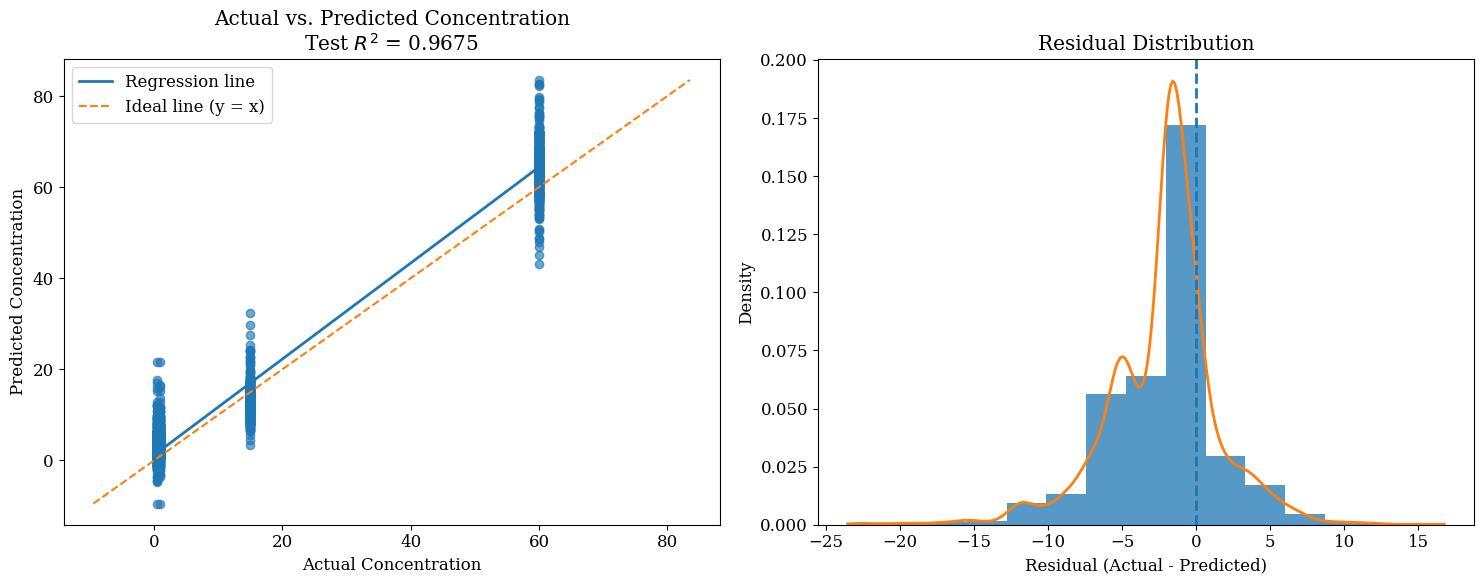

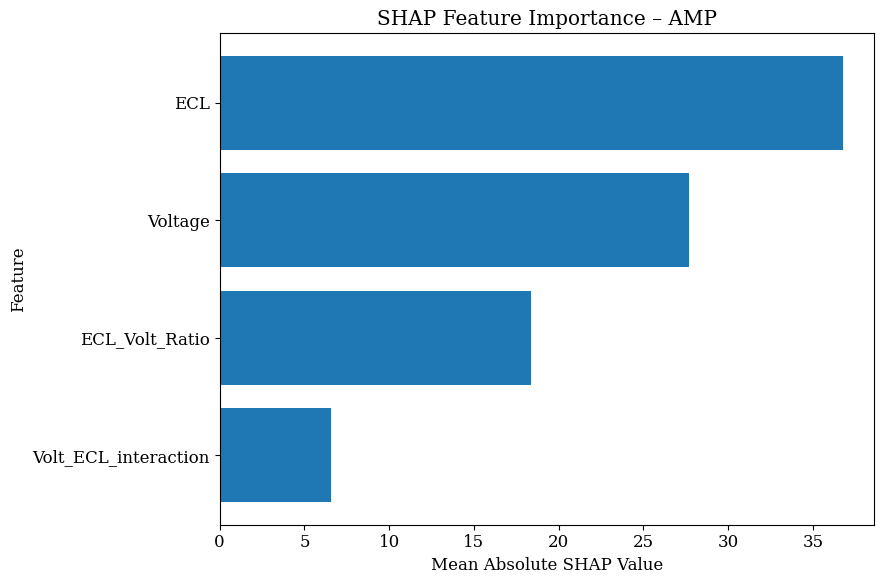

Fitting 5 folds for each of 81 candidates, totalling 405 fits


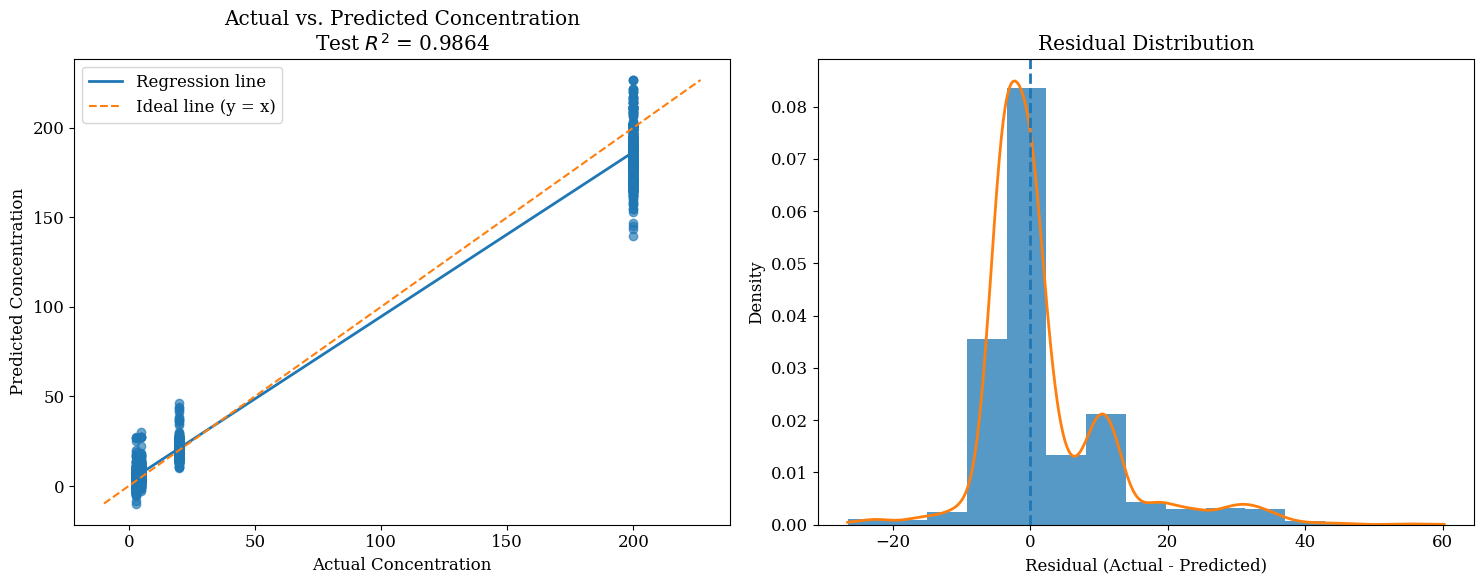

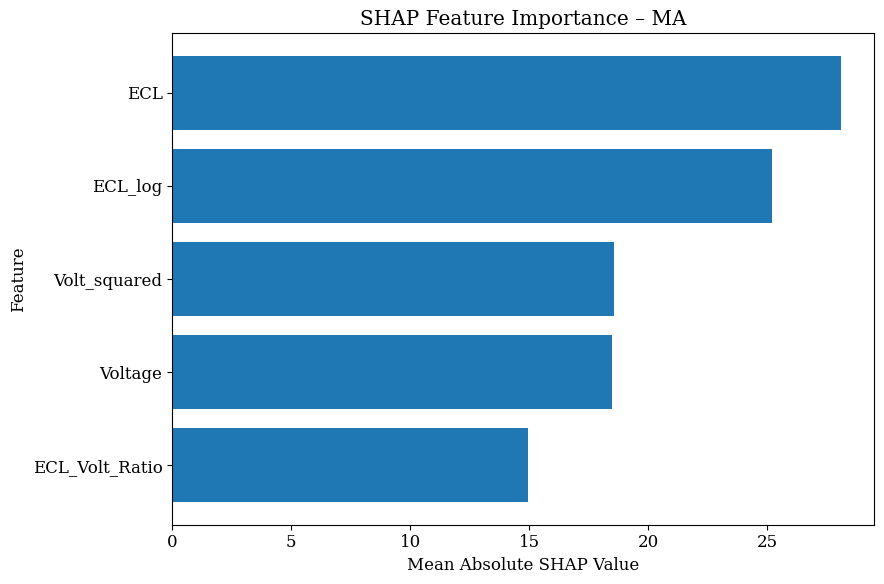

,Dataset,Model,Train R2,Train RMSE,Train MAE,Validation R2,Validation RMSE,Validation MAE,Test R2,Test RMSE,Test MAE,Best Parameters
0,AMP,CatBoost,0.9980,2.9514,1.5575,0.9754,10.3661,6.9940,0.9675,4.3841,3.1923,"{'depth': 6, 'iterations': 1000, 'l2_leaf_reg'..."
1,MA,CatBoost,0.9975,3.3074,1.6696,0.8839,25.4849,12.3456,0.9864,9.6712,6.0113,"{'depth': 6, 'iterations': 1000, 'l2_leaf_reg'..."



AMP
Model: /content/MA_AMP_Temporary_Results_20260722_021754/Best_CatBoost_Model_AMP.cbm
Performance figure: /content/MA_AMP_Temporary_Results_20260722_021754/AMP_CatBoost_Performance.png
SHAP figure: /content/MA_AMP_Temporary_Results_20260722_021754/AMP_CatBoost_SHAP_Bar.png
Best parameters: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.1}

MA
Model: /content/MA_AMP_Temporary_Results_20260722_021754/Best_CatBoost_Model_MA.cbm
Performance figure: /content/MA_AMP_Temporary_Results_20260722_021754/MA_CatBoost_Performance.png
SHAP figure: /content/MA_AMP_Temporary_Results_20260722_021754/MA_CatBoost_SHAP_Bar.png
Best parameters: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.1}


In [ ]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    GridSearchCV,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

from catboost import CatBoostRegressor


RANDOM_STATE = 42
TEST_SIZE = 0.20
N_CV_SPLITS = 5


available_fonts = [
    font.name
    for font in fm.fontManager.ttflist
]

chosen_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "DejaVu Serif"
)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [chosen_font]
plt.rcParams["font.size"] = 12


run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

save_base_path = os.path.join(
    "/content",
    f"MA_AMP_Temporary_Results_{run_timestamp}",
)

os.makedirs(
    save_base_path,
    exist_ok=True,
)


DATASET_CONFIGS = {
    "AMP": {
        "data": amp_data.copy(),
        "features": [
            "Voltage",
            "ECL",
            "ECL_Volt_Ratio",
            "Volt_ECL_interaction",
        ],
        "feature_engineering": "AMP",
        "catboost_param_grid": {
            "iterations": [1000],
            "learning_rate": [0.1],
            "depth": [6],
            "l2_leaf_reg": [3],
        },
    },

    "MA": {
        "data": ma_data_clean.copy(),
        "features": [
            "Voltage",
            "ECL",
            "Volt_squared",
            "ECL_log",
            "ECL_Volt_Ratio",
        ],
        "feature_engineering": "MA",
        "catboost_param_grid": {
            "iterations": [600, 800, 1000],
            "learning_rate": [0.03, 0.05, 0.1],
            "depth": [6, 8, 10],
            "l2_leaf_reg": [3, 5, 7],
        },
    },
}


def create_features(
    df: pd.DataFrame,
    feature_type: str,
) -> pd.DataFrame:
    data = df.copy()

    if feature_type == "AMP":
        data["ECL_Volt_Ratio"] = (
            data["ECL"]
            / (data["Voltage"] + 1e-6)
        )

        data["Volt_ECL_interaction"] = (
            data["Voltage"]
            * data["ECL"]
        )

    elif feature_type == "MA":
        data["Volt_squared"] = (
            data["Voltage"] ** 2
        )

        data["ECL_log"] = np.log1p(
            data["ECL"]
        )

        data["ECL_Volt_Ratio"] = (
            data["ECL"]
            / (data["Voltage"] + 1e-6)
        )

    data = data.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return data


def calculate_metrics(
    y_true,
    y_pred,
):
    return {
        "R2": r2_score(
            y_true,
            y_pred,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
    }


def create_performance_figure(
    dataset_name,
    y_test,
    test_predictions,
    test_metrics,
    output_directory,
):
    actual_values = np.asarray(y_test)
    predicted_values = np.asarray(
        test_predictions
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6),
    )

    axes[0].scatter(
        actual_values,
        predicted_values,
        alpha=0.65,
    )

    regression_coefficients = np.polyfit(
        actual_values,
        predicted_values,
        deg=1,
    )

    regression_line = np.poly1d(
        regression_coefficients
    )

    sorted_actual = np.sort(
        actual_values
    )

    axes[0].plot(
        sorted_actual,
        regression_line(sorted_actual),
        linewidth=2,
        label="Regression line",
    )

    minimum_value = min(
        actual_values.min(),
        predicted_values.min(),
    )

    maximum_value = max(
        actual_values.max(),
        predicted_values.max(),
    )

    axes[0].plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        linestyle="--",
        linewidth=1.5,
        label="Ideal line (y = x)",
    )

    axes[0].set_title(
        f"Actual vs. Predicted Concentration\n"
        f"Test $R^2$ = {test_metrics['R2']:.4f}"
    )

    axes[0].set_xlabel(
        "Actual Concentration"
    )

    axes[0].set_ylabel(
        "Predicted Concentration"
    )

    axes[0].legend()

    residuals = (
        actual_values
        - predicted_values
    )

    axes[1].hist(
        residuals,
        bins=15,
        density=True,
        alpha=0.75,
    )

    if len(np.unique(residuals)) > 1:
        from scipy.stats import gaussian_kde

        density_estimator = gaussian_kde(
            residuals
        )

        residual_range = np.linspace(
            residuals.min(),
            residuals.max(),
            300,
        )

        axes[1].plot(
            residual_range,
            density_estimator(
                residual_range
            ),
            linewidth=2,
        )

    axes[1].axvline(
        0,
        linestyle="--",
        linewidth=2,
    )

    axes[1].set_title(
        "Residual Distribution"
    )

    axes[1].set_xlabel(
        "Residual (Actual - Predicted)"
    )

    axes[1].set_ylabel(
        "Density"
    )

    figure.tight_layout()

    performance_path = os.path.join(
        output_directory,
        f"{dataset_name}_CatBoost_Performance.png",
    )

    figure.savefig(
        performance_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return performance_path


def create_shap_bar_figure(
    dataset_name,
    model,
    X_test,
    features,
    output_directory,
):
    explainer = shap.TreeExplainer(
        model
    )

    shap_values = explainer.shap_values(
        X_test
    )

    mean_absolute_shap = np.mean(
        np.abs(shap_values),
        axis=0,
    )

    shap_table = pd.DataFrame(
        {
            "Feature": features,
            "Mean Absolute SHAP Value":
                mean_absolute_shap,
        }
    ).sort_values(
        by="Mean Absolute SHAP Value",
        ascending=True,
    )

    figure, axis = plt.subplots(
        figsize=(9, 6),
    )

    axis.barh(
        shap_table["Feature"],
        shap_table[
            "Mean Absolute SHAP Value"
        ],
    )

    axis.set_title(
        f"SHAP Feature Importance – {dataset_name}"
    )

    axis.set_xlabel(
        "Mean Absolute SHAP Value"
    )

    axis.set_ylabel(
        "Feature"
    )

    figure.tight_layout()

    shap_path = os.path.join(
        output_directory,
        f"{dataset_name}_CatBoost_SHAP_Bar.png",
    )

    figure.savefig(
        shap_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return shap_table, shap_path


saved_outputs = {}
model_results = []


for dataset_name, config in DATASET_CONFIGS.items():
    data = create_features(
        config["data"],
        config["feature_engineering"],
    )

    features = config["features"]
    target = "Concentration"

    data = (
        data[
            features + [target]
        ]
        .dropna()
        .reset_index(drop=True)
    )

    group_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    development_indices, test_indices = next(
        group_splitter.split(
            X=data[features],
            y=data[target],
            groups=data[target],
        )
    )

    X_development = data.iloc[
        development_indices
    ][features]

    y_development = data.iloc[
        development_indices
    ][target]

    development_groups = data.iloc[
        development_indices
    ][target]

    X_test = data.iloc[
        test_indices
    ][features]

    y_test = data.iloc[
        test_indices
    ][target]

    number_of_splits = min(
        N_CV_SPLITS,
        development_groups.nunique(),
    )

    if number_of_splits < 2:
        raise ValueError(
            f"{dataset_name}: Not enough groups "
            "for GroupKFold."
        )

    cross_validation = GroupKFold(
        n_splits=number_of_splits
    )

    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
    }

    catboost_model = CatBoostRegressor(
        random_state=RANDOM_STATE,
        loss_function="RMSE",
        verbose=0,
        allow_writing_files=False,
    )

    grid_search = GridSearchCV(
        estimator=catboost_model,
        param_grid=config[
            "catboost_param_grid"
        ],
        cv=cross_validation,
        scoring=scoring,
        refit="r2",
        n_jobs=-1,
        verbose=1,
    )

    grid_search.fit(
        X_development,
        y_development,
        groups=development_groups,
    )

    best_catboost = (
        grid_search.best_estimator_
    )

    best_index = (
        grid_search.best_index_
    )

    train_predictions = (
        best_catboost.predict(
            X_development
        )
    )

    test_predictions = (
        best_catboost.predict(
            X_test
        )
    )

    train_metrics = calculate_metrics(
        y_development,
        train_predictions,
    )

    validation_metrics = {
        "R2": grid_search.cv_results_[
            "mean_test_r2"
        ][best_index],

        "RMSE": np.sqrt(
            -grid_search.cv_results_[
                "mean_test_mse"
            ][best_index]
        ),

        "MAE": -grid_search.cv_results_[
            "mean_test_mae"
        ][best_index],
    }

    test_metrics = calculate_metrics(
        y_test,
        test_predictions,
    )

    model_path = os.path.join(
        save_base_path,
        f"Best_CatBoost_Model_{dataset_name}.cbm",
    )

    best_catboost.save_model(
        model_path
    )

    performance_path = (
        create_performance_figure(
            dataset_name=dataset_name,
            y_test=y_test,
            test_predictions=test_predictions,
            test_metrics=test_metrics,
            output_directory=save_base_path,
        )
    )

    shap_table, shap_path = (
        create_shap_bar_figure(
            dataset_name=dataset_name,
            model=best_catboost,
            X_test=X_test,
            features=features,
            output_directory=save_base_path,
        )
    )

    saved_outputs[dataset_name] = {
        "Model": model_path,
        "Performance Figure":
            performance_path,
        "SHAP Figure": shap_path,
        "Best Parameters":
            grid_search.best_params_,
        "SHAP Table": shap_table,
    }

    model_results.append(
        {
            "Dataset": dataset_name,
            "Model": "CatBoost",
            "Train R2":
                train_metrics["R2"],
            "Train RMSE":
                train_metrics["RMSE"],
            "Train MAE":
                train_metrics["MAE"],
            "Validation R2":
                validation_metrics["R2"],
            "Validation RMSE":
                validation_metrics["RMSE"],
            "Validation MAE":
                validation_metrics["MAE"],
            "Test R2":
                test_metrics["R2"],
            "Test RMSE":
                test_metrics["RMSE"],
            "Test MAE":
                test_metrics["MAE"],
            "Best Parameters":
                grid_search.best_params_,
        }
    )


model_results_df = pd.DataFrame(
    model_results
)

display(
    model_results_df.round(4)
)

for dataset_name, output_info in (
    saved_outputs.items()
):
    print(
        f"\n{dataset_name}"
    )
    print(
        f"Model: {output_info['Model']}"
    )
    print(
        "Performance figure: "
        f"{output_info['Performance Figure']}"
    )
    print(
        "SHAP figure: "
        f"{output_info['SHAP Figure']}"
    )
    print(
        "Best parameters: "
        f"{output_info['Best Parameters']}"
    )

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd


AMP_FILE = Path(
    "/content/drive/MyDrive/BIOREGE Cloud/SENSOR/"
    "MA-AMP Sensor/MA-AMP ML/"
    "AMP linear range-ECL measurement.xlsx"
)

MA_FILE = Path(
    "/content/drive/MyDrive/BIOREGE Cloud/SENSOR/"
    "MA-AMP Sensor/MA-AMP ML/"
    "MA linear range-ECL measurement.xlsx"
)


def process_amp_simple(
    path: Path,
) -> pd.DataFrame:
    df = pd.read_excel(
        path,
        header=None,
    )

    concentrations = df.iloc[
        0,
        2:
    ].values

    data = df.iloc[
        2:,
        [1] + list(
            range(
                2,
                df.shape[1],
            )
        ),
    ].copy()

    data.columns = [
        "Voltage"
    ] + list(concentrations)

    df_long = data.melt(
        id_vars="Voltage",
        var_name="Concentration",
        value_name="ECL",
    )

    df_long = (
        df_long
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .dropna()
        .reset_index(drop=True)
    )

    return df_long


def process_ma_fixed(
    path: Path,
) -> pd.DataFrame:
    df = pd.read_excel(
        path,
        header=None,
    )

    concentrations = df.iloc[
        2,
        2:
    ].values

    data = df.iloc[
        3:,
        [1] + list(
            range(
                2,
                df.shape[1],
            )
        ),
    ].copy()

    data.columns = [
        "Voltage"
    ] + list(concentrations)

    df_long = data.melt(
        id_vars="Voltage",
        var_name="Concentration",
        value_name="ECL",
    )

    df_long = (
        df_long
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .dropna()
        .reset_index(drop=True)
    )

    return df_long


if not AMP_FILE.exists():
    raise FileNotFoundError(
        f"AMP file not found: {AMP_FILE}"
    )

if not MA_FILE.exists():
    raise FileNotFoundError(
        f"MA file not found: {MA_FILE}"
    )


amp_data = process_amp_simple(
    AMP_FILE
)

ma_data_clean = process_ma_fixed(
    MA_FILE
)


print(
    "AMP shape:",
    amp_data.shape,
)

print(
    "MA shape:",
    ma_data_clean.shape,
)

AMP shape: (15219, 3)
MA shape: (13617, 3)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


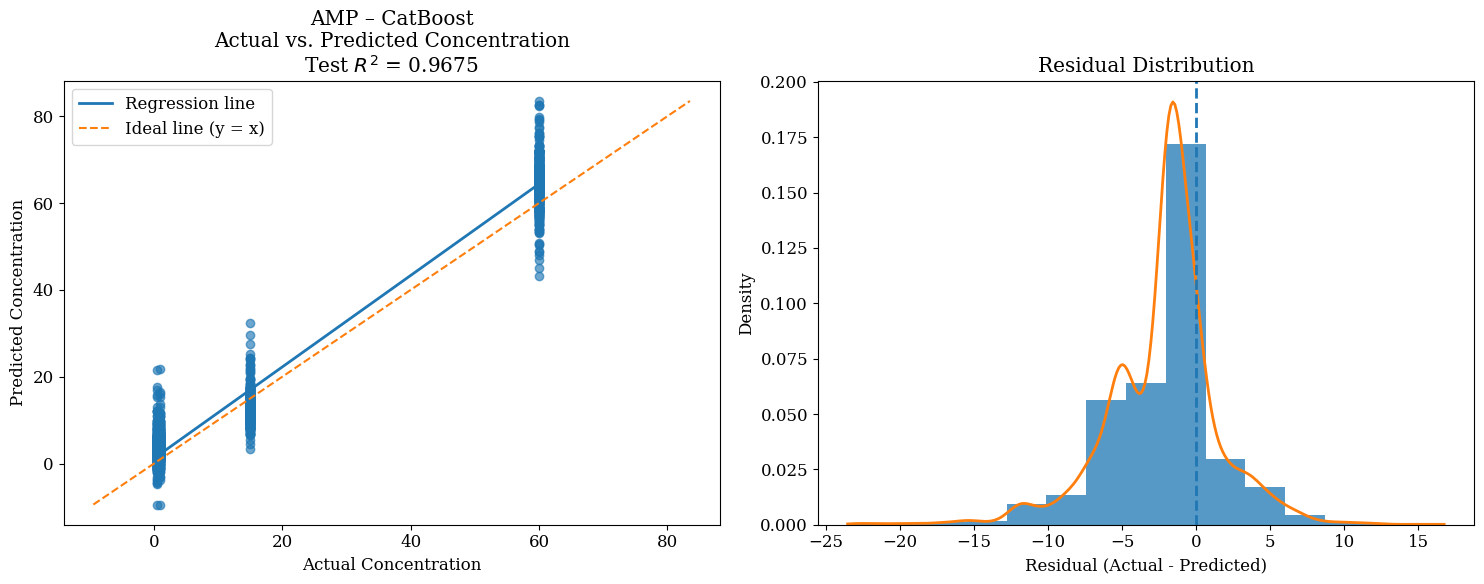

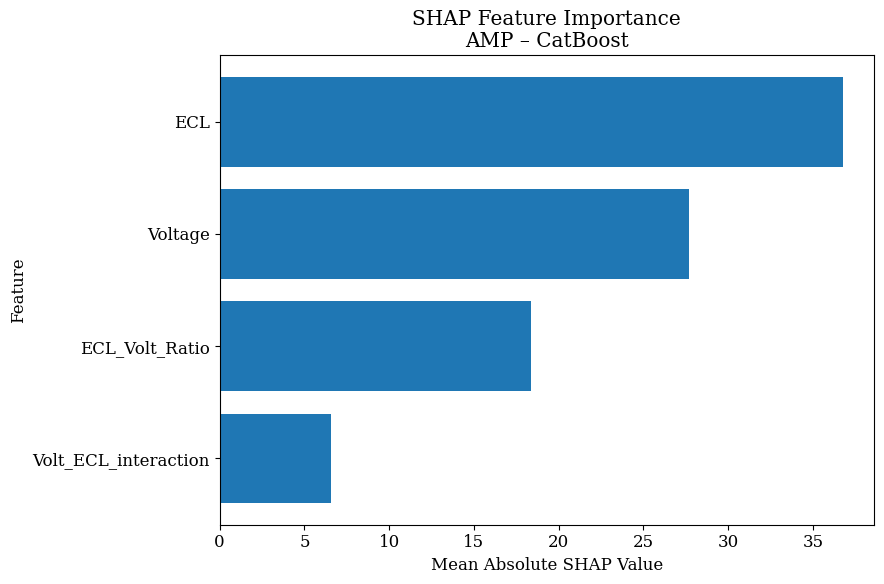

,Dataset,Model,Train R2,Train RMSE,Train MAE,Validation R2,Validation RMSE,Validation MAE,Test R2,Test RMSE,Test MAE
0,AMP,CatBoost,0.9980,2.9514,1.5575,0.9754,10.3661,6.994,0.9675,4.3841,3.1923
1,AMP,XGBoost,0.9978,3.0705,1.5983,0.9606,12.5105,9.723,0.9124,7.1941,4.7822



Output directory: /content/En_Ciktilar

AMP BEST MODEL
Selected model: CatBoost
Validation R2: 0.9754
Test R2: 0.9675
Model path: /content/En_Ciktilar/Best_Model_AMP_CatBoost.cbm
Performance figure: /content/En_Ciktilar/AMP_Best_Model_Performance.png
SHAP figure: /content/En_Ciktilar/AMP_Best_Model_SHAP_Bar.png
Best parameters: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.1}


In [7]:
import os

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    GridSearchCV,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

from catboost import CatBoostRegressor
from xgboost import XGBRegressor


RANDOM_STATE = 42
TEST_SIZE = 0.20
N_CV_SPLITS = 5


available_fonts = [
    font.name
    for font in fm.fontManager.ttflist
]

chosen_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "DejaVu Serif"
)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [chosen_font]
plt.rcParams["font.size"] = 12


save_base_path = "/content/En_Ciktilar"

os.makedirs(
    save_base_path,
    exist_ok=True,
)


DATASET_CONFIGS = {
    "AMP": {
        "data": amp_data.copy(),
        "features": [
            "Voltage",
            "ECL",
            "ECL_Volt_Ratio",
            "Volt_ECL_interaction",
        ],
        "feature_engineering": "AMP",
        "param_grids": {
              "CatBoost": {
            'iterations': [600, 800, 1000],
            'learning_rate': [0.03, 0.05, 0.1],
            'depth': [6, 8, 10],
            'l2_leaf_reg': [3, 5, 7]
        },
            "XGBoost": {
                "n_estimators": [400, 600],
                "learning_rate": [0.01, 0.05, 0.1],
                "max_depth": [4, 6, 8],
                "subsample": [0.8, 1.0],
        },
    },

    "MA": {
        "data": ma_data_clean.copy(),
        "features": [
            "Voltage",
            "ECL",
            "Volt_squared",
            "ECL_log",
            "ECL_Volt_Ratio",
        ],
        "feature_engineering": "MA",
        "param_grids": {
            "CatBoost": {
                "iterations": [600, 800, 1000],
                "learning_rate": [0.03, 0.05, 0.1],
                "depth": [6, 8, 10],
                "l2_leaf_reg": [3, 5, 7],
            },
            "XGBoost": {
                "n_estimators": [400, 600],
                "learning_rate": [0.01, 0.05, 0.1],
                "max_depth": [4, 6, 8],
                "subsample": [0.8, 1.0],
            },
        },
    },
}
}


def create_features(
    df: pd.DataFrame,
    feature_type: str,
) -> pd.DataFrame:
    data = df.copy()

    if feature_type == "AMP":
        data["ECL_Volt_Ratio"] = (
            data["ECL"]
            / (data["Voltage"] + 1e-6)
        )

        data["Volt_ECL_interaction"] = (
            data["Voltage"]
            * data["ECL"]
        )

    elif feature_type == "MA":
        data["Volt_squared"] = (
            data["Voltage"] ** 2
        )

        data["ECL_log"] = np.log1p(
            data["ECL"]
        )

        data["ECL_Volt_Ratio"] = (
            data["ECL"]
            / (data["Voltage"] + 1e-6)
        )

    data = data.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return data


def get_base_models():
    return {
        "CatBoost": CatBoostRegressor(
            random_state=RANDOM_STATE,
            loss_function="RMSE",
            verbose=0,
            allow_writing_files=False,
        ),

        "XGBoost": XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            objective="reg:squarederror",
        ),
    }


def calculate_metrics(
    y_true,
    y_pred,
):
    return {
        "R2": r2_score(
            y_true,
            y_pred,
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),

        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
    }


def create_performance_figure(
    dataset_name,
    model_name,
    y_test,
    test_predictions,
    test_metrics,
    output_directory,
):
    actual_values = np.asarray(
        y_test
    )

    predicted_values = np.asarray(
        test_predictions
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6),
    )

    axes[0].scatter(
        actual_values,
        predicted_values,
        alpha=0.65,
    )

    regression_coefficients = np.polyfit(
        actual_values,
        predicted_values,
        deg=1,
    )

    regression_line = np.poly1d(
        regression_coefficients
    )

    sorted_actual = np.sort(
        actual_values
    )

    axes[0].plot(
        sorted_actual,
        regression_line(sorted_actual),
        linewidth=2,
        label="Regression line",
    )

    minimum_value = min(
        actual_values.min(),
        predicted_values.min(),
    )

    maximum_value = max(
        actual_values.max(),
        predicted_values.max(),
    )

    axes[0].plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        linestyle="--",
        linewidth=1.5,
        label="Ideal line (y = x)",
    )

    axes[0].set_title(
        f"{dataset_name} – {model_name}\n"
        f"Actual vs. Predicted Concentration\n"
        f"Test $R^2$ = {test_metrics['R2']:.4f}"
    )

    axes[0].set_xlabel(
        "Actual Concentration"
    )

    axes[0].set_ylabel(
        "Predicted Concentration"
    )

    axes[0].legend()

    residuals = (
        actual_values
        - predicted_values
    )

    axes[1].hist(
        residuals,
        bins=15,
        density=True,
        alpha=0.75,
    )

    if len(np.unique(residuals)) > 1:
        from scipy.stats import gaussian_kde

        density_estimator = gaussian_kde(
            residuals
        )

        residual_range = np.linspace(
            residuals.min(),
            residuals.max(),
            300,
        )

        axes[1].plot(
            residual_range,
            density_estimator(
                residual_range
            ),
            linewidth=2,
        )

    axes[1].axvline(
        0,
        linestyle="--",
        linewidth=2,
    )

    axes[1].set_title(
        "Residual Distribution"
    )

    axes[1].set_xlabel(
        "Residual (Actual - Predicted)"
    )

    axes[1].set_ylabel(
        "Density"
    )

    figure.tight_layout()

    performance_path = os.path.join(
        output_directory,
        f"{dataset_name}_Best_Model_Performance.png",
    )

    figure.savefig(
        performance_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return performance_path


def create_shap_bar_figure(
    dataset_name,
    model_name,
    model,
    X_test,
    features,
    output_directory,
):
    explainer = shap.TreeExplainer(
        model
    )

    shap_values = explainer.shap_values(
        X_test
    )

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    mean_absolute_shap = np.mean(
        np.abs(shap_values),
        axis=0,
    )

    shap_table = pd.DataFrame(
        {
            "Feature": features,
            "Mean Absolute SHAP Value":
                mean_absolute_shap,
        }
    ).sort_values(
        by="Mean Absolute SHAP Value",
        ascending=True,
    )

    figure, axis = plt.subplots(
        figsize=(9, 6),
    )

    axis.barh(
        shap_table["Feature"],
        shap_table[
            "Mean Absolute SHAP Value"
        ],
    )

    axis.set_title(
        f"SHAP Feature Importance\n"
        f"{dataset_name} – {model_name}"
    )

    axis.set_xlabel(
        "Mean Absolute SHAP Value"
    )

    axis.set_ylabel(
        "Feature"
    )

    figure.tight_layout()

    shap_path = os.path.join(
        output_directory,
        f"{dataset_name}_Best_Model_SHAP_Bar.png",
    )

    figure.savefig(
        shap_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return shap_table, shap_path


def save_best_model(
    dataset_name,
    model_name,
    model,
    output_directory,
):
    if model_name == "CatBoost":
        model_path = os.path.join(
            output_directory,
            f"Best_Model_{dataset_name}_CatBoost.cbm",
        )

        model.save_model(
            model_path
        )

    elif model_name == "XGBoost":
        model_path = os.path.join(
            output_directory,
            f"Best_Model_{dataset_name}_XGBoost.json",
        )

        model.save_model(
            model_path
        )

    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )

    return model_path


all_model_results = []
best_outputs = {}


for dataset_name, config in DATASET_CONFIGS.items():
    data = create_features(
        config["data"],
        config["feature_engineering"],
    )

    features = config["features"]
    target = "Concentration"

    data = (
        data[
            features + [target]
        ]
        .dropna()
        .reset_index(drop=True)
    )

    group_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    development_indices, test_indices = next(
        group_splitter.split(
            X=data[features],
            y=data[target],
            groups=data[target],
        )
    )

    X_development = data.iloc[
        development_indices
    ][features]

    y_development = data.iloc[
        development_indices
    ][target]

    development_groups = data.iloc[
        development_indices
    ][target]

    X_test = data.iloc[
        test_indices
    ][features]

    y_test = data.iloc[
        test_indices
    ][target]

    number_of_splits = min(
        N_CV_SPLITS,
        development_groups.nunique(),
    )

    if number_of_splits < 2:
        raise ValueError(
            f"{dataset_name}: Not enough groups "
            "for GroupKFold."
        )

    cross_validation = GroupKFold(
        n_splits=number_of_splits
    )

    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
    }

    base_models = get_base_models()
    dataset_candidates = []

    for model_name in [
        "CatBoost",
        "XGBoost",
    ]:
        grid_search = GridSearchCV(
            estimator=base_models[
                model_name
            ],

            param_grid=config[
                "param_grids"
            ][model_name],

            cv=cross_validation,
            scoring=scoring,
            refit="r2",
            n_jobs=-1,
            verbose=1,
        )

        grid_search.fit(
            X_development,
            y_development,
            groups=development_groups,
        )

        best_model = (
            grid_search.best_estimator_
        )

        best_index = (
            grid_search.best_index_
        )

        train_predictions = (
            best_model.predict(
                X_development
            )
        )

        test_predictions = (
            best_model.predict(
                X_test
            )
        )

        train_metrics = calculate_metrics(
            y_development,
            train_predictions,
        )

        validation_metrics = {
            "R2": grid_search.cv_results_[
                "mean_test_r2"
            ][best_index],

            "RMSE": np.sqrt(
                -grid_search.cv_results_[
                    "mean_test_mse"
                ][best_index]
            ),

            "MAE": -grid_search.cv_results_[
                "mean_test_mae"
            ][best_index],
        }

        test_metrics = calculate_metrics(
            y_test,
            test_predictions,
        )

        result_row = {
            "Dataset": dataset_name,
            "Model": model_name,

            "Train R2":
                train_metrics["R2"],

            "Train RMSE":
                train_metrics["RMSE"],

            "Train MAE":
                train_metrics["MAE"],

            "Validation R2":
                validation_metrics["R2"],

            "Validation RMSE":
                validation_metrics["RMSE"],

            "Validation MAE":
                validation_metrics["MAE"],

            "Test R2":
                test_metrics["R2"],

            "Test RMSE":
                test_metrics["RMSE"],

            "Test MAE":
                test_metrics["MAE"],

            "Best Parameters":
                grid_search.best_params_,
        }

        all_model_results.append(
            result_row
        )

        dataset_candidates.append(
            {
                "Model Name": model_name,
                "Model": best_model,
                "Validation R2":
                    validation_metrics["R2"],
                "Test Predictions":
                    test_predictions,
                "Test Metrics":
                    test_metrics,
                "Best Parameters":
                    grid_search.best_params_,
            }
        )

    best_candidate = max(
        dataset_candidates,
        key=lambda candidate:
            candidate["Validation R2"],
    )

    best_model_name = (
        best_candidate["Model Name"]
    )

    best_model = (
        best_candidate["Model"]
    )

    best_test_predictions = (
        best_candidate[
            "Test Predictions"
        ]
    )

    best_test_metrics = (
        best_candidate[
            "Test Metrics"
        ]
    )

    model_path = save_best_model(
        dataset_name=dataset_name,
        model_name=best_model_name,
        model=best_model,
        output_directory=save_base_path,
    )

    performance_path = (
        create_performance_figure(
            dataset_name=dataset_name,
            model_name=best_model_name,
            y_test=y_test,
            test_predictions=
                best_test_predictions,
            test_metrics=
                best_test_metrics,
            output_directory=
                save_base_path,
        )
    )

    shap_table, shap_path = (
        create_shap_bar_figure(
            dataset_name=dataset_name,
            model_name=best_model_name,
            model=best_model,
            X_test=X_test,
            features=features,
            output_directory=
                save_base_path,
        )
    )

    best_outputs[dataset_name] = {
        "Best Model":
            best_model_name,

        "Model Path":
            model_path,

        "Performance Figure":
            performance_path,

        "SHAP Figure":
            shap_path,

        "Best Parameters":
            best_candidate[
                "Best Parameters"
            ],

        "Validation R2":
            best_candidate[
                "Validation R2"
            ],

        "Test R2":
            best_test_metrics["R2"],

        "SHAP Table":
            shap_table,
    }


all_model_results_df = pd.DataFrame(
    all_model_results
)

display_columns = [
    "Dataset",
    "Model",
    "Train R2",
    "Train RMSE",
    "Train MAE",
    "Validation R2",
    "Validation RMSE",
    "Validation MAE",
    "Test R2",
    "Test RMSE",
    "Test MAE",
]

display(
    all_model_results_df[
        display_columns
    ].round(4)
)


print(
    f"\nOutput directory: "
    f"{save_base_path}"
)

for dataset_name, output_info in (
    best_outputs.items()
):
    print(
        "\n" + "=" * 80
    )

    print(
        f"{dataset_name} BEST MODEL"
    )

    print(
        "=" * 80
    )

    print(
        f"Selected model: "
        f"{output_info['Best Model']}"
    )

    print(
        f"Validation R2: "
        f"{output_info['Validation R2']:.4f}"
    )

    print(
        f"Test R2: "
        f"{output_info['Test R2']:.4f}"
    )

    print(
        f"Model path: "
        f"{output_info['Model Path']}"
    )

    print(
        f"Performance figure: "
        f"{output_info['Performance Figure']}"
    )

    print(
        f"SHAP figure: "
        f"{output_info['SHAP Figure']}"
    )

    print(
        f"Best parameters: "
        f"{output_info['Best Parameters']}"
    )

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


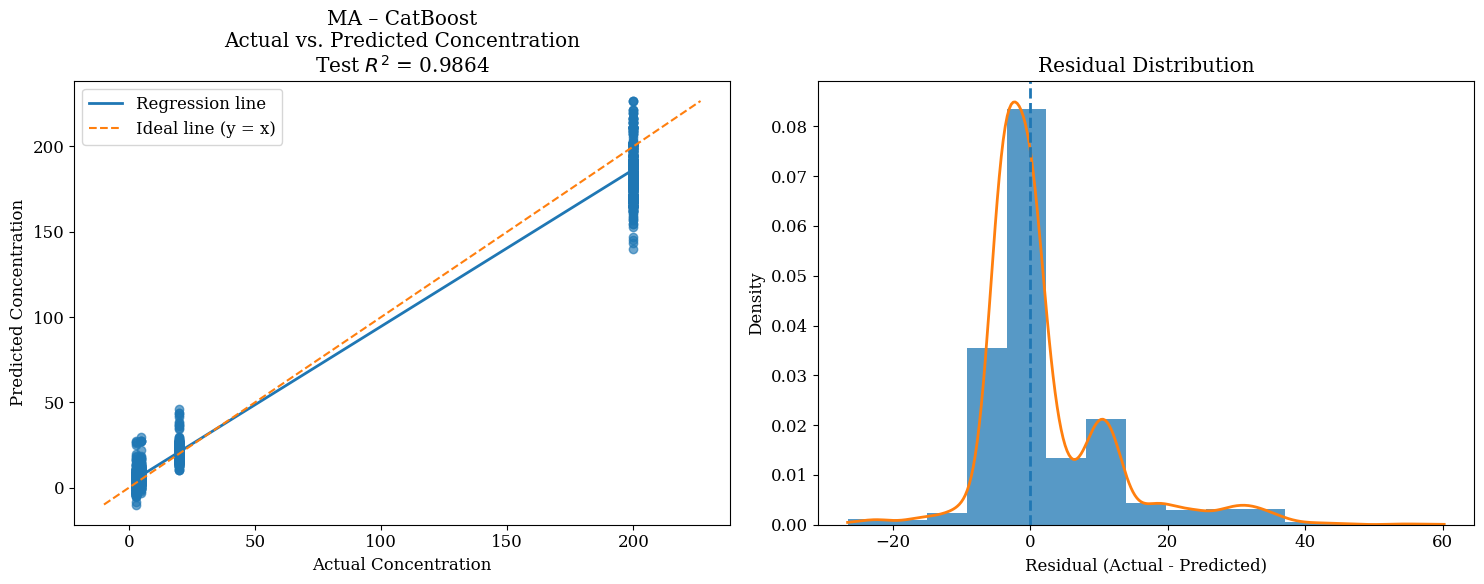

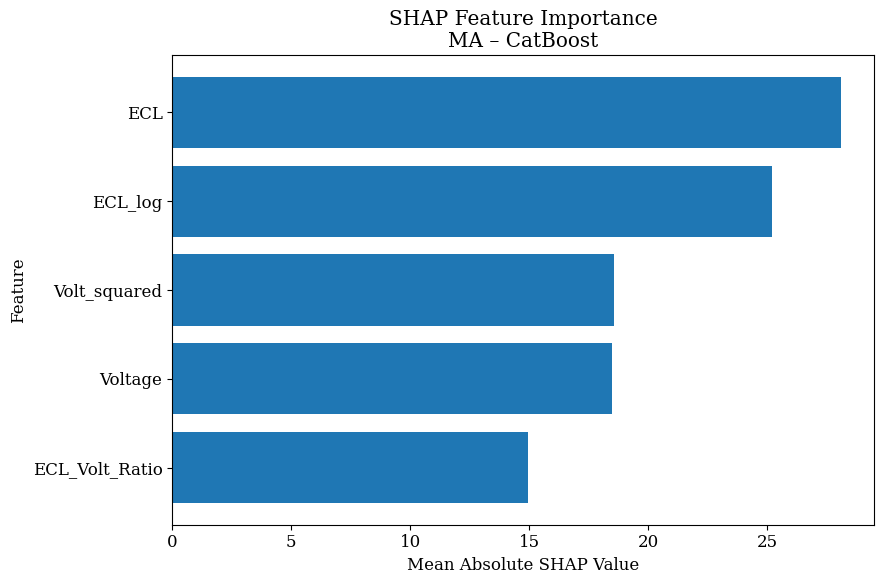

,Dataset,Model,Train R2,Train RMSE,Train MAE,Validation R2,Validation RMSE,Validation MAE,Test R2,Test RMSE,Test MAE
0,MA,CatBoost,0.9975,3.3074,1.6696,0.8839,25.4849,12.3456,0.9864,9.6712,6.0113
1,MA,XGBoost,0.9973,3.4556,1.7007,0.8182,27.9441,14.9429,0.9626,16.0176,10.1536



MA BEST MODEL
Selected model: CatBoost
Validation R2: 0.8839
Test R2: 0.9864
Best parameters: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Model path: /content/En_Ciktilar/Best_Model_MA_CatBoost.cbm
Performance figure: /content/En_Ciktilar/MA_Best_Model_Performance.png
SHAP figure: /content/En_Ciktilar/MA_Best_Model_SHAP_Bar.png
Output directory: /content/En_Ciktilar


In [8]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    GridSearchCV,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

from catboost import CatBoostRegressor
from xgboost import XGBRegressor


RANDOM_STATE = 42
TEST_SIZE = 0.20
N_CV_SPLITS = 5


MA_FILE = Path(
    "/content/drive/MyDrive/BIOREGE Cloud/SENSOR/"
    "MA-AMP Sensor/MA-AMP ML/"
    "MA linear range-ECL measurement.xlsx"
)


save_base_path = "/content/En_Ciktilar"

os.makedirs(
    save_base_path,
    exist_ok=True,
)


available_fonts = [
    font.name
    for font in fm.fontManager.ttflist
]

chosen_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "DejaVu Serif"
)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [chosen_font]
plt.rcParams["font.size"] = 12


def process_ma_fixed(
    path: Path,
) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"MA file not found: {path}"
        )

    df = pd.read_excel(
        path,
        header=None,
    )

    concentrations = df.iloc[
        2,
        2:
    ].values

    data = df.iloc[
        3:,
        [1] + list(
            range(
                2,
                df.shape[1],
            )
        ),
    ].copy()

    data.columns = [
        "Voltage"
    ] + list(concentrations)

    df_long = data.melt(
        id_vars="Voltage",
        var_name="Concentration",
        value_name="ECL",
    )

    df_long = (
        df_long
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .dropna()
        .reset_index(drop=True)
    )

    return df_long


def create_ma_features(
    df: pd.DataFrame,
) -> pd.DataFrame:
    data = df.copy()

    data["Volt_squared"] = (
        data["Voltage"] ** 2
    )

    data["ECL_log"] = np.log1p(
        data["ECL"]
    )

    data["ECL_Volt_Ratio"] = (
        data["ECL"]
        / (data["Voltage"] + 1e-6)
    )

    data = data.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return data


def calculate_metrics(
    y_true,
    y_pred,
):
    return {
        "R2": r2_score(
            y_true,
            y_pred,
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),

        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
    }


def create_performance_figure(
    model_name,
    y_test,
    test_predictions,
    test_metrics,
    output_directory,
):
    actual_values = np.asarray(
        y_test
    )

    predicted_values = np.asarray(
        test_predictions
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6),
    )

    axes[0].scatter(
        actual_values,
        predicted_values,
        alpha=0.65,
    )

    regression_coefficients = np.polyfit(
        actual_values,
        predicted_values,
        deg=1,
    )

    regression_line = np.poly1d(
        regression_coefficients
    )

    sorted_actual = np.sort(
        actual_values
    )

    axes[0].plot(
        sorted_actual,
        regression_line(sorted_actual),
        linewidth=2,
        label="Regression line",
    )

    minimum_value = min(
        actual_values.min(),
        predicted_values.min(),
    )

    maximum_value = max(
        actual_values.max(),
        predicted_values.max(),
    )

    axes[0].plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        linestyle="--",
        linewidth=1.5,
        label="Ideal line (y = x)",
    )

    axes[0].set_title(
        f"MA – {model_name}\n"
        f"Actual vs. Predicted Concentration\n"
        f"Test $R^2$ = {test_metrics['R2']:.4f}"
    )

    axes[0].set_xlabel(
        "Actual Concentration"
    )

    axes[0].set_ylabel(
        "Predicted Concentration"
    )

    axes[0].legend()

    residuals = (
        actual_values
        - predicted_values
    )

    axes[1].hist(
        residuals,
        bins=15,
        density=True,
        alpha=0.75,
    )

    if len(np.unique(residuals)) > 1:
        from scipy.stats import gaussian_kde

        density_estimator = gaussian_kde(
            residuals
        )

        residual_range = np.linspace(
            residuals.min(),
            residuals.max(),
            300,
        )

        axes[1].plot(
            residual_range,
            density_estimator(
                residual_range
            ),
            linewidth=2,
        )

    axes[1].axvline(
        0,
        linestyle="--",
        linewidth=2,
    )

    axes[1].set_title(
        "Residual Distribution"
    )

    axes[1].set_xlabel(
        "Residual (Actual - Predicted)"
    )

    axes[1].set_ylabel(
        "Density"
    )

    figure.tight_layout()

    performance_path = os.path.join(
        output_directory,
        "MA_Best_Model_Performance.png",
    )

    figure.savefig(
        performance_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return performance_path


def create_shap_bar_figure(
    model_name,
    model,
    X_test,
    features,
    output_directory,
):
    explainer = shap.TreeExplainer(
        model
    )

    shap_values = explainer.shap_values(
        X_test
    )

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    mean_absolute_shap = np.mean(
        np.abs(shap_values),
        axis=0,
    )

    shap_table = pd.DataFrame(
        {
            "Feature": features,
            "Mean Absolute SHAP Value":
                mean_absolute_shap,
        }
    ).sort_values(
        by="Mean Absolute SHAP Value",
        ascending=True,
    )

    figure, axis = plt.subplots(
        figsize=(9, 6),
    )

    axis.barh(
        shap_table["Feature"],
        shap_table[
            "Mean Absolute SHAP Value"
        ],
    )

    axis.set_title(
        f"SHAP Feature Importance\n"
        f"MA – {model_name}"
    )

    axis.set_xlabel(
        "Mean Absolute SHAP Value"
    )

    axis.set_ylabel(
        "Feature"
    )

    figure.tight_layout()

    shap_path = os.path.join(
        output_directory,
        "MA_Best_Model_SHAP_Bar.png",
    )

    figure.savefig(
        shap_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return shap_table, shap_path


def save_best_model(
    model_name,
    model,
    output_directory,
):
    if model_name == "CatBoost":
        model_path = os.path.join(
            output_directory,
            "Best_Model_MA_CatBoost.cbm",
        )

        model.save_model(
            model_path
        )

    elif model_name == "XGBoost":
        model_path = os.path.join(
            output_directory,
            "Best_Model_MA_XGBoost.json",
        )

        model.save_model(
            model_path
        )

    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )

    return model_path


ma_data_clean = process_ma_fixed(
    MA_FILE
)

ma_data = create_ma_features(
    ma_data_clean
)


features = [
    "Voltage",
    "ECL",
    "Volt_squared",
    "ECL_log",
    "ECL_Volt_Ratio",
]

target = "Concentration"


ma_data = (
    ma_data[
        features + [target]
    ]
    .dropna()
    .reset_index(drop=True)
)


group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

development_indices, test_indices = next(
    group_splitter.split(
        X=ma_data[features],
        y=ma_data[target],
        groups=ma_data[target],
    )
)


X_development = ma_data.iloc[
    development_indices
][features]

y_development = ma_data.iloc[
    development_indices
][target]

development_groups = ma_data.iloc[
    development_indices
][target]

X_test = ma_data.iloc[
    test_indices
][features]

y_test = ma_data.iloc[
    test_indices
][target]


number_of_splits = min(
    N_CV_SPLITS,
    development_groups.nunique(),
)

if number_of_splits < 2:
    raise ValueError(
        "MA: Not enough groups for GroupKFold."
    )


cross_validation = GroupKFold(
    n_splits=number_of_splits
)


scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
}


models = {
    "CatBoost": CatBoostRegressor(
        random_state=RANDOM_STATE,
        loss_function="RMSE",
        verbose=0,
        allow_writing_files=False,
    ),

    "XGBoost": XGBRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        objective="reg:squarederror",
    ),
}


param_grids = {
    "CatBoost": {
        "iterations": [
            600,
            800,
            1000,
        ],
        "learning_rate": [
            0.03,
            0.05,
            0.1,
        ],
        "depth": [
            6,
            8,
            10,
        ],
        "l2_leaf_reg": [
            3,
            5,
            7,
        ],
    },

    "XGBoost": {
        "n_estimators": [
            400,
            600,
        ],
        "learning_rate": [
            0.01,
            0.05,
            0.1,
        ],
        "max_depth": [
            4,
            6,
            8,
        ],
        "subsample": [
            0.8,
            1.0,
        ],
    },
}


model_results = []
model_candidates = []


for model_name in [
    "CatBoost",
    "XGBoost",
]:
    grid_search = GridSearchCV(
        estimator=models[
            model_name
        ],
        param_grid=param_grids[
            model_name
        ],
        cv=cross_validation,
        scoring=scoring,
        refit="r2",
        n_jobs=-1,
        verbose=1,
    )

    grid_search.fit(
        X_development,
        y_development,
        groups=development_groups,
    )

    best_model = (
        grid_search.best_estimator_
    )

    best_index = (
        grid_search.best_index_
    )

    train_predictions = best_model.predict(
        X_development
    )

    test_predictions = best_model.predict(
        X_test
    )

    train_metrics = calculate_metrics(
        y_development,
        train_predictions,
    )

    validation_metrics = {
        "R2": grid_search.cv_results_[
            "mean_test_r2"
        ][best_index],

        "RMSE": np.sqrt(
            -grid_search.cv_results_[
                "mean_test_mse"
            ][best_index]
        ),

        "MAE": -grid_search.cv_results_[
            "mean_test_mae"
        ][best_index],
    }

    test_metrics = calculate_metrics(
        y_test,
        test_predictions,
    )

    model_results.append(
        {
            "Dataset": "MA",
            "Model": model_name,
            "Train R2":
                train_metrics["R2"],
            "Train RMSE":
                train_metrics["RMSE"],
            "Train MAE":
                train_metrics["MAE"],
            "Validation R2":
                validation_metrics["R2"],
            "Validation RMSE":
                validation_metrics["RMSE"],
            "Validation MAE":
                validation_metrics["MAE"],
            "Test R2":
                test_metrics["R2"],
            "Test RMSE":
                test_metrics["RMSE"],
            "Test MAE":
                test_metrics["MAE"],
            "Best Parameters":
                grid_search.best_params_,
        }
    )

    model_candidates.append(
        {
            "Model Name": model_name,
            "Model": best_model,
            "Validation R2":
                validation_metrics["R2"],
            "Test Predictions":
                test_predictions,
            "Test Metrics":
                test_metrics,
            "Best Parameters":
                grid_search.best_params_,
        }
    )


best_candidate = max(
    model_candidates,
    key=lambda candidate:
        candidate["Validation R2"],
)


best_model_name = (
    best_candidate["Model Name"]
)

best_model = (
    best_candidate["Model"]
)

best_test_predictions = (
    best_candidate[
        "Test Predictions"
    ]
)

best_test_metrics = (
    best_candidate[
        "Test Metrics"
    ]
)


model_path = save_best_model(
    model_name=best_model_name,
    model=best_model,
    output_directory=save_base_path,
)


performance_path = create_performance_figure(
    model_name=best_model_name,
    y_test=y_test,
    test_predictions=
        best_test_predictions,
    test_metrics=
        best_test_metrics,
    output_directory=
        save_base_path,
)


shap_table, shap_path = (
    create_shap_bar_figure(
        model_name=best_model_name,
        model=best_model,
        X_test=X_test,
        features=features,
        output_directory=
            save_base_path,
    )
)


model_results_df = pd.DataFrame(
    model_results
)


display_columns = [
    "Dataset",
    "Model",
    "Train R2",
    "Train RMSE",
    "Train MAE",
    "Validation R2",
    "Validation RMSE",
    "Validation MAE",
    "Test R2",
    "Test RMSE",
    "Test MAE",
]


display(
    model_results_df[
        display_columns
    ].round(4)
)


print(
    "\n" + "=" * 80
)

print(
    "MA BEST MODEL"
)

print(
    "=" * 80
)

print(
    f"Selected model: "
    f"{best_model_name}"
)

print(
    f"Validation R2: "
    f"{best_candidate['Validation R2']:.4f}"
)

print(
    f"Test R2: "
    f"{best_test_metrics['R2']:.4f}"
)

print(
    f"Best parameters: "
    f"{best_candidate['Best Parameters']}"
)

print(
    f"Model path: "
    f"{model_path}"
)

print(
    f"Performance figure: "
    f"{performance_path}"
)

print(
    f"SHAP figure: "
    f"{shap_path}"
)

print(
    f"Output directory: "
    f"{save_base_path}"
)